<a href="https://colab.research.google.com/github/jgybels/CEE-593---Module-4/blob/main/GEOL581_Module5_SlopeStability_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GEOL 581 — Module 5: Slope Stability Analyses (Improved Notebook Template)

**Student name:** _<your name>_  
**NetID / UIN:** _<your NetID or UIN>_  
**Date:** _<YYYY-MM-DD>_

---

## How to use this notebook

1. **Run cells from top to bottom** (Kernel → Restart & Run All before you submit).
2. Keep **units consistent**:
   - Cohesion **c′** in **kPa** (= kN/m²)  
   - Unit weights **γ** in **kN/m³**  
   - Lengths in **m**  
   - Angles in **degrees** (convert to radians inside code)
3. Write short explanations in the provided **Markdown response blocks**.
4. Your goal is *not* to build a “black box” — it’s to show you can translate textbook free‑body diagrams and assumptions (Figs. 10.31–10.38) into working, checkable code.

> **Academic integrity note:** You may discuss concepts with classmates, but your code, plots, and written explanations must be your own.

---

## What you will build

### Part 1 — Plane (Infinite) Slope Sliding
Implement and test an **infinite slope** factor of safety function for dry and saturated cases.

### Part 2 — Rotational Sliding + Method of Slices
Compute factors of safety for a **circular slip surface** using:
- **Ordinary method of slices** (Fellenius)
- **Bishop simplified** (iterative)

…and compare two pore-pressure assumptions:
- **“Membrane” (ru method)**: constant pore-pressure ratio along the slip surface
- **“Flow‑net‑like” (phreatic line)**: pore pressure varies slice‑by‑slice from a water table line

### Part 3 — Sensitivity Study
Run at least **two parameter sweeps** and interpret trends (and threshold behavior near FOS ≈ 1).

---

## References you must cite in your writeup
Use the textbook sections and figures referenced in the assignment prompt (e.g., **Figs. 10.31–10.38**) and note where each assumption comes from.


In [9]:
# ---- Notebook setup (run first) ----
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility (only needed if you introduce randomness later)
np.random.seed(0)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)


numpy: 2.0.2
pandas: 2.2.2
matplotlib: 3.10.0


In [1]:
# ---- Small helper utilities ----
def deg2rad(deg: float) -> float:
    return math.radians(deg)

def _require(condition: bool, msg: str):
    if not condition:
        raise ValueError(msg)

def pretty_fs(fs: float) -> str:
    if fs == math.inf:
        return "∞"
    if fs != fs:  # NaN check
        return "NaN"
    return f"{fs:.3f}"


## Part 1 — Plane Sliding (Infinite Slope)

### Background (connect to Figs. 10.31–10.32)

For an infinite slope with a potential failure plane parallel to the ground surface:

\[
FS = \frac{c' + (\sigma_n - u)\tan\phi'}{\tau}
\]

A common stress approximation at **vertical depth** \(z\) is:

\[
\sigma_n = \gamma z \cos^2\beta, \qquad \tau = \gamma z \sin\beta \cos\beta
\]

A simple way to include groundwater is to use:
- **m-method**: \(u = \gamma_w (m z)\cos^2\beta\), where \(m \in [0,1]\) is the fraction of the failure depth that is saturated (water table parallel to the slope)
- **ru-method**: \(u = r_u \sigma_n\)

> Your textbook may define these slightly differently depending on geometry. Use this notebook as a computational framework — *you must explain your assumptions* and connect them to the relevant figures.

### Your tasks

1. Read the code for `infinite_slope_fs()` and confirm (by hand) that the dry, cohesionless limit reduces to:
\[
FS = \frac{\tan\phi'}{\tan\beta}
\]
2. Add **one extension** (choose one):
   - surcharge load \(q\) (kPa) on the ground surface, **or**
   - a convenience wrapper that accepts **ru** directly, **or**
   - support for a **layered unit weight** (dry γ above water table, saturated γ below).
3. In a Markdown cell below, explain how your final expression relates to **Figs. 10.31–10.32**.


In [10]:
def infinite_slope_fs(
    c_kpa: float,
    phi_deg: float,
    beta_deg: float,
    z_m: float,
    gamma_soil_kN_m3: float,
    *,
    gamma_w_kN_m3: float = 9.81,
    m: float | None = 0.0,
    ru: float | None = None,
    surcharge_kpa: float = 0.0,
) -> float:
    """
    Factor of Safety (FS) for an *infinite slope* with a planar failure surface parallel to the slope.

    Parameters
    ----------
    c_kpa : float
        Effective cohesion c' in kPa (= kN/m^2).
    phi_deg : float
        Effective friction angle φ' in degrees.
    beta_deg : float
        Slope angle β in degrees (0 < β < 90).
    z_m : float
        Vertical depth to the potential failure plane (m).
    gamma_soil_kN_m3 : float
        Total unit weight of soil γ (kN/m^3). (For advanced cases you may distinguish γ_dry, γ_sat, γ_sub.)
    gamma_w_kN_m3 : float, optional
        Unit weight of water γ_w (kN/m^3). Default 9.81.
    m : float or None, optional
        m-method saturation ratio in [0,1]. If m=None, no groundwater is applied unless ru is provided.
    ru : float or None, optional
        ru-method pore pressure ratio u/σ_n. If provided, it overrides m.
    surcharge_kpa : float, optional
        Uniform vertical surcharge q (kPa) applied at the ground surface. Default 0.

    Returns
    -------
    float
        Factor of safety (dimensionless).
    """
    _require(z_m > 0, "z_m must be > 0")
    _require(gamma_soil_kN_m3 > 0, "gamma_soil_kN_m3 must be > 0")
    _require(0 < beta_deg < 90, "beta_deg must be between 0 and 90 degrees")
    _require(phi_deg >= 0, "phi_deg must be >= 0")
    _require(c_kpa >= 0, "c_kpa must be >= 0")
    _require(surcharge_kpa >= 0, "surcharge_kpa must be >= 0")

    beta = deg2rad(beta_deg)
    phi = deg2rad(phi_deg)

    # Total vertical stress = soil overburden + surcharge
    sigma_v = gamma_soil_kN_m3 * z_m + surcharge_kpa

    # Stresses on a plane parallel to the slope at vertical depth z
    sigma_n = (gamma_soil_kN_m3 * z_m + surcharge_kpa) * (math.cos(beta) ** 2)
    tau = (gamma_soil_kN_m3 * z_m + surcharge_kpa) * (math.sin(beta) * math.cos(beta))

    if tau == 0:
        return math.inf

    # Pore pressure u
    if ru is not None:
        _require(0 <= ru < 1.0, "ru should be in [0, 1) for typical problems")
        u = ru * sigma_n
    else:
        if m is None:
            u = 0.0
        else:
            _require(0 <= m <= 1.0, "m must be in [0, 1]")
            u = gamma_w_kN_m3 * (m * z_m) * (math.cos(beta) ** 2)

    sigma_eff = max(0.0, sigma_n - u)

    resisting = c_kpa + sigma_eff * math.tan(phi)
    FS = resisting / tau
    return FS


# --- quick sanity checks (do not delete) ---
# 1) Dry, cohesionless => tan(phi)/tan(beta)
phi_test, beta_test = 30.0, 25.0
fs_expected = math.tan(deg2rad(phi_test)) / math.tan(deg2rad(beta_test))
fs_model = infinite_slope_fs(
    c_kpa=0.0, phi_deg=phi_test, beta_deg=beta_test,
    z_m=2.0, gamma_soil_kN_m3=18.0, m=0.0
)
print("Sanity check FS:", pretty_fs(fs_model), " expected:", pretty_fs(fs_expected))

# 2) If beta > phi and no cohesion, FS should be < 1 (dry)
fs_unstable = infinite_slope_fs(
    c_kpa=0.0, phi_deg=25.0, beta_deg=35.0,
    z_m=2.0, gamma_soil_kN_m3=18.0, m=0.0
)
print("Unstable example (should be < 1):", pretty_fs(fs_unstable))


Sanity check FS: 1.238  expected: 1.238
Unstable example (should be < 1): 0.666


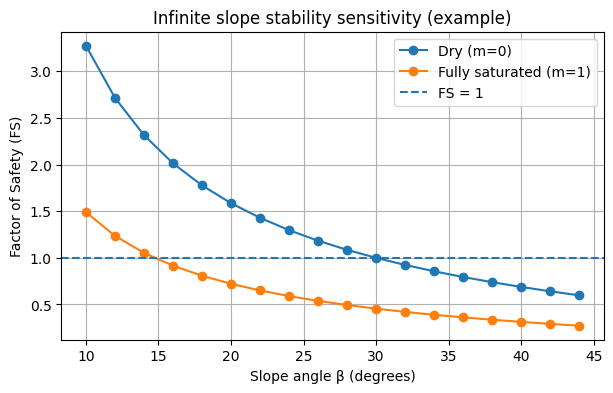

In [11]:
# ---- Part 1 mini-study: FS vs slope angle (dry vs saturated) ----
phi = 30.0
c = 0.0
z = 2.0
gamma = 18.0

beta_vals = np.arange(10, 46, 2)
fs_dry = [infinite_slope_fs(c, phi, b, z, gamma, m=0.0) for b in beta_vals]
fs_sat = [infinite_slope_fs(c, phi, b, z, gamma, m=1.0) for b in beta_vals]

plt.figure(figsize=(7, 4))
plt.plot(beta_vals, fs_dry, marker="o", label="Dry (m=0)")
plt.plot(beta_vals, fs_sat, marker="o", label="Fully saturated (m=1)")
plt.axhline(1.0, linestyle="--", label="FS = 1")
plt.xlabel("Slope angle β (degrees)")
plt.ylabel("Factor of Safety (FS)")
plt.title("Infinite slope stability sensitivity (example)")
plt.grid(True)
plt.legend()
plt.show()


### Part 1 — Written response (required)

In 6–10 sentences, explain:

- What free‑body diagram / force balance corresponds to your `infinite_slope_fs()` implementation?
- Where do \(\sigma_n\), \(\tau\), and \(u\) come from in the textbook figures?
- Which assumptions are most limiting for real slopes (layering, unsaturated conditions, non-parallel seepage, etc.)?

_Your response here:_  

The free body diameter / force balance represents a vertical slice of soil bounded by a circular failure plane at the bottom of the slice, parrallel to the slope. The circular failure is made up of multiple thin vertical slices of soil.

Sigma n represents the normal stress and tau represents the shear stres from the vertical overburden + surchage acting perpendicular to the failure plane. u represents the hydrostaic pressure acting within the soil mass, which reduces the effective noraml stress and shear strength.

The most limiting assumptions for real slopes are: That the slope is homogenous, infinetely long, and that the failure plane is parallel to the ground surface.


## Part 2 — Rotational Sliding: Method of Slices

### Background (connect to Figs. 10.34–10.38)

Rotational failures are commonly modeled with **limit equilibrium** methods that divide the sliding mass into vertical slices.

In this notebook you will compute FS for a **single prescribed circular slip surface** using two common methods:

- **Ordinary method of slices (Fellenius):** force equilibrium with simplifying assumptions (no interslice forces).
- **Bishop simplified:** moment equilibrium with an iterative correction (accounts for interslice normal forces, ignores interslice shear).

You will also compare two groundwater assumptions:

- **Membrane / ru method:** a constant pore-pressure ratio \(r_u\) along the slip surface.
- **Flow‑net‑like method:** pore pressure computed from a **phreatic surface line**; \(u_i = \gamma_w (h_w - y_{base,i})\) where positive.

> Real flow nets are more complex. This is a controlled “physics‑informed” approximation that is still far better than random pore pressures.

### Your tasks

1. Run the baseline example and confirm you can reproduce the plotted geometry.
2. Compare **Fellenius vs Bishop** FS values for the same pore-pressure model.
3. Compare **ru vs phreatic-line** pore pressure assumptions for the same limit-equilibrium method.
4. In a Markdown cell below, explain (with reference to the textbook figures) **why** the FS values differ.


In [ ]:
# ---- Geometry helpers for a simple 2D slope cross-section ----
def make_slope_surface(H_m: float, beta_deg: float):
    """
    Piecewise ground surface:
      - horizontal plateau for x <= 0 at elevation H
      - planar slope face from (0, H) to (L, 0)
      - horizontal ground for x >= L at elevation 0
    """
    _require(H_m > 0, "H_m must be > 0")
    _require(0 < beta_deg < 90, "beta_deg must be between 0 and 90 degrees")
    beta = deg2rad(beta_deg)
    L = H_m / math.tan(beta)

    def y_top(x: float) -> float:
        if x <= 0.0:
            return H_m
        if x < L:
            return H_m - x * math.tan(beta)
        return 0.0

    return L, y_top


def circle_centers_from_two_points_radius(p1, p2, R):
    """
    Return the two possible circle centers for a circle of radius R through p1 and p2.
    """
    x1, y1 = p1
    x2, y2 = p2
    dx, dy = x2 - x1, y2 - y1
    d = math.hypot(dx, dy)
    _require(d > 0, "p1 and p2 must be different points")
    _require(R >= d / 2, "Radius too small to connect the two points")

    mx, my = (x1 + x2) / 2, (y1 + y2) / 2
    h = math.sqrt(max(0.0, R**2 - (d / 2) ** 2))

    # perpendicular unit vector to chord
    ux, uy = (-dy / d, dx / d)

    c1 = (mx + h * ux, my + h * uy)
    c2 = (mx - h * ux, my - h * uy)
    return c1, c2


def choose_circle_and_branch(p1, p2, R, y_top_func, n_check=50):
    """
    Choose (center, branch) for y = y_c ± sqrt(R^2 - (x-x_c)^2) such that the arc between p1 and p2
    lies below the ground surface y_top_func as much as possible.

    Returns
    -------
    (x_c, y_c, R, sign)
      sign = +1 uses the upper branch, sign = -1 uses the lower branch
    """
    c1, c2 = circle_centers_from_two_points_radius(p1, p2, R)
    candidates = []
    x_min, x_max = min(p1[0], p2[0]), max(p1[0], p2[0])

    for (x_c, y_c) in [c1, c2]:
        for sign in (+1, -1):
            def y_circle(x):
                rad = R**2 - (x - x_c) ** 2
                if rad < 0:
                    return float("nan")
                return y_c + sign * math.sqrt(rad)

            # must pass through endpoints (within tolerance)
            if abs(y_circle(p1[0]) - p1[1]) > 1e-3:
                continue
            if abs(y_circle(p2[0]) - p2[1]) > 1e-3:
                continue

            xs = np.linspace(x_min, x_max, n_check)
            violations = 0
            for x in xs:
                yb = y_circle(x)
                yt = y_top_func(x)
                if np.isnan(yb) or yb > yt + 1e-6:
                    violations += 1

            candidates.append((violations, x_c, y_c, sign))

    _require(len(candidates) > 0, "Could not find a valid circle/branch combination")

    candidates.sort(key=lambda t: t[0])
    violations, x_c, y_c, sign = candidates[0]
    if violations > 0:
        print(f"Warning: chosen circle has {violations}/{n_check} below-surface violations.")
    return (x_c, y_c, R, sign)


def make_circle_slip_surface(circle_params):
    """
    Build a callable y_base(x) for a selected circle slip surface.
    circle_params = (x_c, y_c, R, sign)
    """
    x_c, y_c, R, sign = circle_params

    def y_base(x: float) -> float:
        rad = R**2 - (x - x_c) ** 2
        if rad < 0:
            return float("nan")
        return y_c + sign * math.sqrt(rad)

    return y_base


In [ ]:
def generate_vertical_slices(
    x_left: float,
    x_right: float,
    n_slices: int,
    y_top_func,
    y_base_func,
    *,
    gamma_soil_kN_m3: float,
) -> pd.DataFrame:
    """
    Discretize the sliding mass between x_left and x_right into n vertical slices.

    Returns a DataFrame with per-slice geometry and weights (per unit thickness out of plane).
    """
    _require(n_slices >= 4, "Use at least 4 slices (>=10 is better)")
    _require(x_right > x_left, "x_right must be > x_left")
    _require(gamma_soil_kN_m3 > 0, "gamma_soil_kN_m3 must be > 0")

    xs = np.linspace(x_left, x_right, n_slices + 1)
    recs = []

    for i in range(n_slices):
        xL, xR = float(xs[i]), float(xs[i + 1])
        b = xR - xL

        yTL, yTR = float(y_top_func(xL)), float(y_top_func(xR))
        yBL, yBR = float(y_base_func(xL)), float(y_base_func(xR))

        _require(np.isfinite(yBL) and np.isfinite(yBR), "Slip surface undefined for some x in the slice domain")

        tL, tR = yTL - yBL, yTR - yBR
        area = 0.5 * b * (tL + tR)  # trapezoid area
        _require(area > 0, f"Non-positive slice area for slice {i}. Check geometry.")

        # Base dip to the right (positive if y decreases as x increases)
        dy_base = yBL - yBR
        alpha = math.atan2(dy_base, b)  # radians, expected positive for typical right-moving slides
        l = b / math.cos(alpha)         # base length (straight chord approximation)

        x_mid = 0.5 * (xL + xR)
        y_base_mid = float(y_base_func(x_mid))
        y_top_mid = float(y_top_func(x_mid))

        W = gamma_soil_kN_m3 * area  # kN/m (per unit thickness)

        recs.append({
            "i": i,
            "xL": xL, "xR": xR, "b": b,
            "yTL": yTL, "yTR": yTR,
            "yBL": yBL, "yBR": yBR,
            "x_mid": x_mid,
            "y_top_mid": y_top_mid,
            "y_base_mid": y_base_mid,
            "area": area,
            "W": W,
            "alpha_rad": alpha,
            "alpha_deg": math.degrees(alpha),
            "l": l,
        })

    return pd.DataFrame.from_records(recs)


def pore_pressure_ru(df: pd.DataFrame, ru: float) -> np.ndarray:
    """
    Constant ru pore pressure ratio model:
      u_i = ru * sigma_n,i  where sigma_n,i ≈ (W cos α) / l
    """
    _require(0 <= ru < 1.0, "ru should be in [0, 1)")

    W = df["W"].to_numpy()
    alpha = df["alpha_rad"].to_numpy()
    l = df["l"].to_numpy()

    sigma_n = (W * np.cos(alpha)) / l  # kPa
    u = ru * sigma_n
    return u


def make_phreatic_line(H_m: float, L_m: float, y_wt_at_crest: float, y_wt_at_toe: float, y_top_func):
    """
    Create a simple straight-line phreatic surface between:
      (0, y_wt_at_crest) and (L, y_wt_at_toe),
    capped so it cannot exceed the ground surface.
    """
    def y_wt(x: float) -> float:
        if x <= 0:
            y = y_wt_at_crest
        elif x >= L_m:
            y = y_wt_at_toe
        else:
            y = y_wt_at_crest + (y_wt_at_toe - y_wt_at_crest) * (x / L_m)

        return min(y, y_top_func(x))  # cap to ground surface
    return y_wt


def pore_pressure_from_phreatic(df: pd.DataFrame, y_wt_func, gamma_w_kN_m3: float = 9.81) -> np.ndarray:
    """
    Hydrostatic pore pressure relative to a phreatic surface:
      u_i = γ_w * max(0, y_wt(x_mid) - y_base_mid)
    """
    x = df["x_mid"].to_numpy()
    yb = df["y_base_mid"].to_numpy()
    ywt = np.array([y_wt_func(float(xi)) for xi in x])
    head = np.maximum(0.0, ywt - yb)
    u = gamma_w_kN_m3 * head  # kPa
    return u


In [ ]:
def fos_fellenius(df: pd.DataFrame, c_kpa: float, phi_deg: float, u_kpa: np.ndarray | None = None) -> float:
    """
    Ordinary method of slices (Fellenius / Swedish circle):
      FS = Σ [ c' l_i + (W_i cos α_i - u_i l_i) tan φ' ]  /  Σ [ W_i sin α_i ]
    """
    _require(c_kpa >= 0, "c_kpa must be >= 0")
    _require(phi_deg >= 0, "phi_deg must be >= 0")

    phi = deg2rad(phi_deg)
    W = df["W"].to_numpy()
    alpha = df["alpha_rad"].to_numpy()
    l = df["l"].to_numpy()

    if u_kpa is None:
        u = np.zeros_like(W)
    else:
        u = np.asarray(u_kpa, dtype=float)
        _require(len(u) == len(df), "u_kpa must match number of slices")

    resisting = c_kpa * l + (W * np.cos(alpha) - u * l) * math.tan(phi)
    driving = W * np.sin(alpha)

    denom = driving.sum()
    if denom == 0:
        return math.inf
    return resisting.sum() / denom


def fos_bishop_simplified(
    df: pd.DataFrame,
    c_kpa: float,
    phi_deg: float,
    u_kpa: np.ndarray | None = None,
    *,
    max_iter: int = 200,
    tol: float = 1e-6,
) -> float:
    """
    Bishop simplified (iterative):
      FS = Σ [ (c' b_i + (W_i - u_i b_i) tan φ') / (1 + (tan φ' tan α_i)/FS ) ]  /  Σ [ W_i sin α_i ]
    """
    _require(c_kpa >= 0, "c_kpa must be >= 0")
    _require(phi_deg >= 0, "phi_deg must be >= 0")

    phi = deg2rad(phi_deg)
    tan_phi = math.tan(phi)

    W = df["W"].to_numpy()
    alpha = df["alpha_rad"].to_numpy()
    b = df["b"].to_numpy()

    if u_kpa is None:
        u = np.zeros_like(W)
    else:
        u = np.asarray(u_kpa, dtype=float)
        _require(len(u) == len(df), "u_kpa must match number of slices")

    denom = (W * np.sin(alpha)).sum()
    if denom == 0:
        return math.inf

    FS = 1.0
    for _ in range(max_iter):
        m_i = 1.0 / (1.0 + (tan_phi * np.tan(alpha)) / FS)
        num_i = c_kpa * b + (W - u * b) * tan_phi
        FS_new = (num_i * m_i).sum() / denom
        if abs(FS_new - FS) < tol:
            return FS_new
        FS = FS_new

    print("Warning: Bishop iteration did not converge within max_iter")
    return FS


In [ ]:
# ---- Baseline scenario (edit these values for your experiments) ----
H = 10.0          # m
beta = 30.0       # degrees
gamma = 18.0      # kN/m^3
c_eff = 10.0      # kPa
phi_eff = 25.0    # degrees

# Slip surface endpoints: entry on the plateau, exit at the toe
x_back = 5.0                           # m behind the crest (x = -x_back)
L, y_top = make_slope_surface(H, beta) # toe is at x = L
p_entry = (-x_back, H)
p_exit = (L, 0.0)

# Pick a radius that produces a reasonable deep-seated circle
R = 25.0  # m (try 18–40 m)

circle_params = choose_circle_and_branch(p_entry, p_exit, R, y_top)
x_c, y_c, R, sign = circle_params
y_base = make_circle_slip_surface(circle_params)

# Discretize
n_slices = 12
df = generate_vertical_slices(p_entry[0], p_exit[0], n_slices, y_top, y_base, gamma_soil_kN_m3=gamma)

df.head()


In [ ]:
# ---- Groundwater models ----
ru_membrane = 0.20  # constant pore-pressure ratio

ywt_crest = 8.0     # m elevation at crest (x=0)
ywt_toe = 0.0       # m elevation at toe   (x=L)

y_wt = make_phreatic_line(H, L, ywt_crest, ywt_toe, y_top)

u_ru = pore_pressure_ru(df, ru=ru_membrane)
u_phreatic = pore_pressure_from_phreatic(df, y_wt)

# Compute FS values
results = []
for gw_name, u in [("Dry (u=0)", None), ("Membrane (ru)", u_ru), ("Phreatic line", u_phreatic)]:
    fs_fell = fos_fellenius(df, c_eff, phi_eff, u_kpa=u)
    fs_bish = fos_bishop_simplified(df, c_eff, phi_eff, u_kpa=u)
    results.append((gw_name, fs_fell, fs_bish))

pd.DataFrame(results, columns=["Groundwater model", "FS (Fellenius)", "FS (Bishop)"])


In [ ]:
# ---- Plot the slope, slip surface, water table, and slices ----
xs = np.linspace(p_entry[0], p_exit[0], 300)
yt = np.array([y_top(float(x)) for x in xs])
yb = np.array([y_base(float(x)) for x in xs])
ywt = np.array([y_wt(float(x)) for x in xs])

plt.figure(figsize=(8, 4.5))
plt.plot(xs, yt, label="Ground surface")
plt.plot(xs, yb, label="Slip surface (circle)")
plt.plot(xs, ywt, linestyle="--", label="Phreatic line")

# slice boundaries
for x in np.linspace(p_entry[0], p_exit[0], n_slices + 1):
    plt.plot([x, x], [y_base(float(x)), y_top(float(x))], linewidth=0.8)

plt.scatter([p_entry[0], p_exit[0]], [p_entry[1], p_exit[1]], s=30, label="Slip endpoints")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Baseline slope geometry and slip surface")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()


### Part 2 — Written response (required)

In 8–12 sentences (with equations where helpful), address:

- Why do Fellenius and Bishop give different FS values for the same geometry?
- Which groundwater model (ru vs phreatic line) was more destabilizing in your baseline run, and why?
- Relate your observations to **Figs. 10.37–10.38** (membrane vs flow-net interpretations, seepage forces, pore pressure distribution).

_Your response here:_  


## Part 3 — Sensitivity Analysis (Required)

A sensitivity study is only useful if it is **systematic** and **well documented**.

### Requirements
Choose **at least two** parameters to vary (examples below) and produce:

1. **One plot per parameter** showing FS trends for *both* groundwater models.
2. A **table** summarizing the minimum FS observed and the parameter value where FS first drops below 1.

### Suggested parameters to sweep
- Slope angle β
- Friction angle φ′
- Cohesion c′
- Water table elevation at crest (ywt_crest)
- ru (for membrane model)
- Slip surface radius R or the entry setback x_back (geometry sensitivity)

> Tip: Use Bishop FS as your primary metric (it is usually less conservative than Fellenius, but more realistic for many circular problems). You may still report both.


In [ ]:
def run_slope_case(
    *,
    H: float,
    beta: float,
    gamma: float,
    c_eff: float,
    phi_eff: float,
    x_back: float,
    R: float,
    n_slices: int,
    ru_membrane: float,
    ywt_crest: float,
    ywt_toe: float,
):
    L, y_top = make_slope_surface(H, beta)
    p_entry = (-x_back, H)
    p_exit = (L, 0.0)

    circle_params = choose_circle_and_branch(p_entry, p_exit, R, y_top)
    y_base = make_circle_slip_surface(circle_params)

    df = generate_vertical_slices(p_entry[0], p_exit[0], n_slices, y_top, y_base, gamma_soil_kN_m3=gamma)

    y_wt = make_phreatic_line(H, L, ywt_crest, ywt_toe, y_top)

    u_ru = pore_pressure_ru(df, ru=ru_membrane)
    u_ph = pore_pressure_from_phreatic(df, y_wt)

    out = {
        "fs_bishop_dry": fos_bishop_simplified(df, c_eff, phi_eff, u_kpa=None),
        "fs_bishop_ru": fos_bishop_simplified(df, c_eff, phi_eff, u_kpa=u_ru),
        "fs_bishop_phreatic": fos_bishop_simplified(df, c_eff, phi_eff, u_kpa=u_ph),
        "fs_fellenius_dry": fos_fellenius(df, c_eff, phi_eff, u_kpa=None),
        "fs_fellenius_ru": fos_fellenius(df, c_eff, phi_eff, u_kpa=u_ru),
        "fs_fellenius_phreatic": fos_fellenius(df, c_eff, phi_eff, u_kpa=u_ph),
        "L": L,
        "circle_params": circle_params,
    }
    return out


# --- baseline (reuse values above) ---
baseline = dict(
    H=H, beta=beta, gamma=gamma, c_eff=c_eff, phi_eff=phi_eff,
    x_back=x_back, R=R, n_slices=n_slices,
    ru_membrane=ru_membrane, ywt_crest=ywt_crest, ywt_toe=ywt_toe
)

run_slope_case(**baseline)


In [ ]:
# ---- Example sweep 1: vary ru (membrane model) ----
ru_vals = np.linspace(0.0, 0.5, 11)

rows = []
for ru in ru_vals:
    case = dict(baseline)
    case["ru_membrane"] = float(ru)
    out = run_slope_case(**case)
    rows.append({
        "ru": ru,
        "FS Bishop (ru model)": out["fs_bishop_ru"],
        "FS Bishop (phreatic model)": out["fs_bishop_phreatic"],
        "FS Bishop (dry)": out["fs_bishop_dry"],
    })

df_ru = pd.DataFrame(rows)

plt.figure(figsize=(7, 4))
plt.plot(df_ru["ru"], df_ru["FS Bishop (ru model)"], marker="o", label="Bishop + ru")
plt.plot(df_ru["ru"], df_ru["FS Bishop (phreatic model)"], marker="o", label="Bishop + phreatic")
plt.axhline(1.0, linestyle="--", label="FS = 1")
plt.xlabel("ru (membrane pore-pressure ratio)")
plt.ylabel("Factor of Safety (FS)")
plt.title("Sensitivity to ru (example)")
plt.grid(True)
plt.legend()
plt.show()

df_ru.head()


In [ ]:
# ---- Example sweep 2: vary friction angle φ' ----
phi_vals = np.arange(18.0, 37.0, 2.0)

rows = []
for phi_val in phi_vals:
    case = dict(baseline)
    case["phi_eff"] = float(phi_val)
    out = run_slope_case(**case)
    rows.append({
        "phi_eff_deg": phi_val,
        "FS Bishop (ru model)": out["fs_bishop_ru"],
        "FS Bishop (phreatic model)": out["fs_bishop_phreatic"],
    })

df_phi = pd.DataFrame(rows)

plt.figure(figsize=(7, 4))
plt.plot(df_phi["phi_eff_deg"], df_phi["FS Bishop (ru model)"], marker="o", label="Bishop + ru")
plt.plot(df_phi["phi_eff_deg"], df_phi["FS Bishop (phreatic model)"], marker="o", label="Bishop + phreatic")
plt.axhline(1.0, linestyle="--", label="FS = 1")
plt.xlabel("Friction angle φ' (degrees)")
plt.ylabel("Factor of Safety (FS)")
plt.title("Sensitivity to friction angle (example)")
plt.grid(True)
plt.legend()
plt.show()

df_phi.head()


### Part 3 — Interpretation (required)

For each parameter you varied:

1. Describe the trend (linear? nonlinear? threshold-like near FS≈1?)
2. Identify **approximately** where FS crosses 1 (if it does).
3. Explain the physics behind the trend using the textbook figures/ideas (changes in normal stress, pore pressure, shear strength, etc.).
4. State which model (ru vs phreatic) you consider more realistic for the scenario you tested.

_Your response here:_  


## Conclusion (Required)

Write a concise conclusion (≈ 8–12 sentences) that answers:

- What slope configuration(s) were most critical (lowest FS), and why?
- How did groundwater assumptions change the stability prediction?
- What is one limitation of your approach and one realistic improvement you would make in a future model?

_Your conclusion here:_  


## Optional Extensions (Extra Credit / Exploration)

Choose **one** if you want to go beyond the minimum:

- Scan over multiple circles (vary R and/or x_back) and find the **minimum FS** in your search grid.
- Add a **seismic coefficient** (pseudo-static horizontal acceleration) and evaluate FS sensitivity.
- Implement a different limit equilibrium method (e.g., Janbu simplified) and compare.

Document what you did and include any additional plots/tables.
